                        "HOW STRUCTURAL SOCIO-ECONOMIC FACTORS RELATE TO LATER IT GROWTH ACROSS INDIA"

INTRODUCTION :

IT sector is one of the fastest growing sector in modern India.The Indian IT-BPM sector is projected to contribute 10% to the country’s GDP in FY 2026.While Bengaluru is known as 'Silicon Valley of India' ,other cities like Hyderabad ,Pune ,Chennai ,Mumbai ,NCR(Delhi,Gurgaon,Noida) ,Kochi are known as major IT hubs in India.How these cities become major IT hubs?Why MNC s are interested more to invest in these places than other Indian cities? This project aims to solve whether there is "LATER" relation of socio-economic factors such as Population,Urbanisation and Literacy in choosing these IT cities in their growing phase.We are considering socio economic factors of year 2011 and IT stats of year 2016-21.
Kindly note that this project is not just an analysis of relation between socio-conomic factors and IT exports whareas it focus on how they are related to LATER IT growth.We are considering both these domains in two different times.

PROBLEM STATEMENT :

1. Do cities with larger populations become major IT hubs later?
2. Is the IT growth of Indian cities related to the literacy rate of their states 5-10 years ago?
3. How does urbanisation affect the future IT potential of a place?

DATASETS :

We are using 4 datasets for this project:
1. Statewise IT exports 👉(https://www.data.gov.in/resource/stateuts-wise-exports-software-technology-parks-india-software-technology-parks-india-stpi) source:data.gov.in
2. Statewise Literacy rate 👉(https://www.data.gov.in/resource/stateuts-wise-literacy-rates-census-2001-and-2011) source:data.gov.in
3. Statewise Population 👉(https://www.rbi.org.in/SCRIPTs/PublicationsView.aspx?id=22789) source:Reserve Bank of India
4. Statewise Urban Population 👉(https://www.rbi.org.in/SCRIPTs/PublicationsView.aspx?id=22791) source:Reserve Bank of India

note that datasets 2,3,4 are based on census 2011.

DATA CLEANING :

1. Due to Andhra Pradesh state partition 2014,IT Export dataset contain datas of Telangana and Andhra Pradesh seperately.
    
    sol : Merge datas of Telangana and Andhra Pradesh to single value of Andhra Pradesh.
       
2. Datasets Literacy,Urbanisation and Population contain datas of Union Territories whearas dataset IT Export do not contain it except for Delhi.
  
    sol : Exclude datas of every Union Territories except Delhi from every dataset.

In [2]:
import pandas as pd

In [3]:
df=pd.read_excel("state population.xlsx",skiprows=3)
df.drop(columns=["Unnamed: 0"],inplace=True)
df.columns=["State","1951","1961","1971","1981","1981","2001","Population 2011"]
df=df[["State","Population 2011"]]
utlist=["Chandigarh",
        "Dadra & Nagar Haveli",
        "Daman & Diu",
        "Lakshadweep",
        "Andaman & Nicobar Islands",
        "Puducherry",
        "Dadra and Nagar Haveli",
        "Daman and Diu",
        "Andaman and Nicobar Islands"
        ]
df=df[~df["State"].isin(utlist)]
df=df.iloc[:-8]
df=df.reset_index(drop=True)
df.head()

,State,Population 2011
0,Andhra Pradesh,84581.0
1,Arunachal Pradesh,1384.0
2,Assam,31206.0
3,Bihar,104099.0
4,Chhattisgarh,25545.0


In [4]:
df2=pd.read_csv("literacy.csv",skiprows=1)
df2.columns=["no.","State","2001","Literacy 2011"]
df2=df2[["State","Literacy 2011"]]
df2=df2[~df2["State"].isin(utlist)]
df2["State"]=df2["State"].replace({"Jammu and Kashmir" : "Jammu & Kashmir","Uttrakhand" : "Uttarakhand"})
df2=df2.reset_index(drop=True)
df2.head()

,State,Literacy 2011
0,Andhra Pradesh,67.02
1,Arunachal Pradesh,65.38
2,Assam,72.19
3,Bihar,61.80
4,Chhattisgarh,70.28


In [5]:
df3=pd.read_csv("it export.csv")
df3.columns=["no","State","2016-17","2017-18","2018-19","2019-20","2020-21"]
df3=df3[["State","2016-17","2017-18","2018-19","2019-20","2020-21"]]
df3["State"]=df3["State"].replace({"Telangana" : "Andhra Pradesh","Jammu and Kashmir" : "Jammu & Kashmir"})
df3.head()

,State,2016-17,2017-18,2018-19,2019-20,2020-21
0,Karnataka,141846.0,152280.16,169699.08,194473.28,204648.96
1,Maharashtra,69010.0,74580.15,85595.37,91513.90,99732.48
2,Andhra Pradesh,46429.0,50795.82,57527.45,64525.90,71574.19
3,Tamil Nadu,34563.0,36848.70,40457.08,50327.33,47936.28
4,Haryana,20874.0,22182.85,24220.32,26140.64,25017.80


In [6]:
df4=pd.read_excel("urban population.xlsx",skiprows=3)
df4=df4.iloc[:-9]
df4.columns=["no","State","1951","1961","1971","1981","1991","2001","Urban Population 2011"]
df4=df4[["State","Urban Population 2011"]]
df4=df4[~df4["State"].isin(utlist)]
df4=df4.reset_index(drop=True)
df4.head()

,State,Urban Population 2011
0,Andhra Pradesh,28219.0
1,Arunachal Pradesh,317.0
2,Assam,4399.0
3,Bihar,11758.0
4,Chhattisgarh,5937.0


    Completed cleaning of datasets except merging of Andhra and Telangana in IT Export dataset.That can be done using SQL after moving these cleaned datasets to database.

In [7]:
import sqlite3

conn=sqlite3.connect(":memory:")
df.to_sql("State Population",conn,index=False)
df2.to_sql("Literacy",conn,index=False)
df3.to_sql("IT Export",conn,index=False)
df4.to_sql("Urban Population",conn,index=False)

29

In [8]:
q1="""drop table if exists "Cleaned IT Export";
      create table "Cleaned IT Export" as 
      select State,sum("2016-17") as "2016-17",
                   sum("2017-18") as "2017-18",
                   sum("2018-19") as "2018-19",
                   sum("2019-20") as "2019-20",
                   sum("2020-21") as "2020-21"
                   from "IT Export" group by State """
conn.executescript(q1)
conn.commit()

In [9]:
q2="""select * from "Cleaned IT Export" """
dff2=pd.read_sql(q2,conn)
dff2.head()

,State,2016-17,2017-18,2018-19,2019-20,2020-21
0,Andhra Pradesh,46955.69,51498.11,58314.40,65372.67,72457.21
1,Assam,10.50,21.09,22.31,22.27,19.51
2,Bihar,4.65,0.03,0.03,0.00,0.00
3,Chandigarh,758.82,668.27,730.64,573.49,728.74
4,Chhattisgarh,36.79,36.75,63.03,86.77,22.65


Merging of Andhra Pradesh and Telangana has done successfully.Now joining all 4 datasets is left.

In [10]:
q3="""select t1.State,
             t1."Literacy 2011",
             t2."Population 2011",
             t3."Urban Population 2011",
             t4."2016-17",
             t4."2017-18",
             t4."2018-19",
             t4."2019-20",
             t4."2020-21"
        from Literacy t1 left join
             "State Population" t2 on t1.State=t2.State
        left join "Urban Population" t3 on t2.State=t3.State
        left join "Cleaned IT Export" t4 on t3.State=t4.State """

dff3=pd.read_sql(q3,conn)
dff3["2016-17"]=dff3["2016-17"].fillna(0)
dff3["2017-18"]=dff3["2017-18"].fillna(0)
dff3["2018-19"]=dff3["2018-19"].fillna(0)
dff3["2019-20"]=dff3["2019-20"].fillna(0)
dff3["2020-21"]=dff3["2020-21"].fillna(0)
dff3.to_sql("final dataset",conn,if_exists="replace")
dff3

,State,Literacy 2011,Population 2011,Urban Population 2011,2016-17,2017-18,2018-19,2019-20,2020-21
0,Andhra Pradesh,67.02,84581.0,28219.0,46955.69,51498.11,58314.40,65372.67,72457.21
1,Arunachal Pradesh,65.38,1384.0,317.0,0.00,0.00,0.00,0.00,0.00
2,Assam,72.19,31206.0,4399.0,10.50,21.09,22.31,22.27,19.51
3,Bihar,61.80,104099.0,11758.0,4.65,0.03,0.03,0.00,0.00
4,Chhattisgarh,70.28,25545.0,5937.0,36.79,36.75,63.03,86.77,22.65
5,Goa,88.70,1459.0,907.0,85.13,82.79,79.66,137.55,139.10
6,Gujarat,78.03,60440.0,25745.0,2363.50,2681.14,3101.06,3570.80,3982.53
7,Haryana,75.55,25351.0,8842.0,20874.00,22182.85,24220.32,26140.64,25017.80
8,Himachal Pradesh,82.80,6865.0,689.0,6.97,7.58,11.57,5.13,3.66
9,Jammu & Kashmir,67.16,12541.0,3433.0,3.58,3.92,5.30,6.24,6.82


Data Cleaning completed successfully. 🎉

From this table we are going to analyse the relations between given socio-economic factors and later IT growth.For that we are grouping IT Export years to 2 phases.

Phase 1: Pre-COVID (2016-17,2017-18 and 2018-19 years data combined)

Phase 2: Early-COVID (2019-20 and 2020-21 years data combined)

In [11]:
q4="""select State,"Literacy 2011","Population 2011","Urban Population 2011",
    ("2016-17" + "2017-18" + "2018-19") as "Pre-COVID",("2019-20" + "2020-21") as "Early-COVID" 
    from "final dataset" """
dff4=pd.read_sql(q4,conn)
dff4.to_sql("dataset",conn,if_exists="replace")
dff4.head()

,State,Literacy 2011,Population 2011,Urban Population 2011,Pre-COVID,Early-COVID
0,Andhra Pradesh,67.02,84581.0,28219.0,156768.20,137829.88
1,Arunachal Pradesh,65.38,1384.0,317.0,0.00,0.00
2,Assam,72.19,31206.0,4399.0,53.90,41.78
3,Bihar,61.80,104099.0,11758.0,4.71,0.00
4,Chhattisgarh,70.28,25545.0,5937.0,136.57,109.42


We just reshaped the dataset according to our analysis requirement.

DATA ANALYSIS :

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

1. Is the IT growth of Indian cities related to the literacy rate of their states 5-10 years ago?

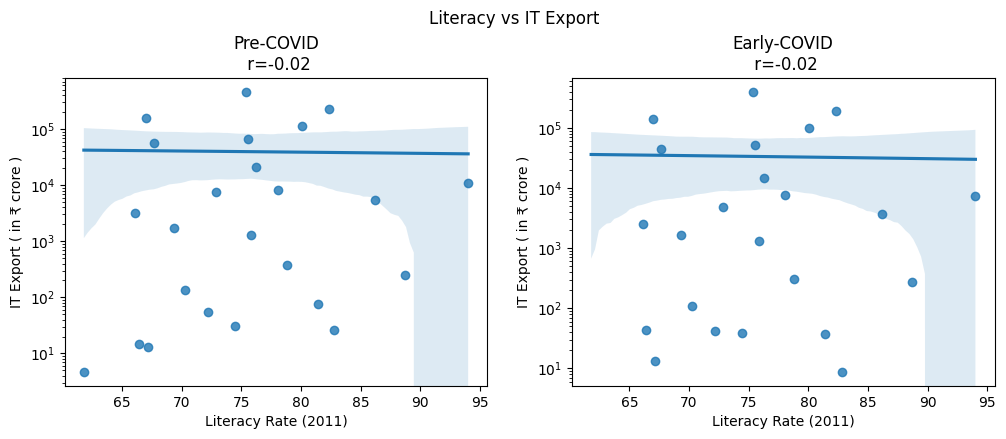

In [13]:
qplt1="""select "Literacy 2011","Pre-COVID","Early-COVID" from dataset """
dfplt1=pd.read_sql(qplt1,conn)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.regplot(
    x="Literacy 2011",y="Pre-COVID",data=dfplt1)

corr1=dfplt1["Literacy 2011"].corr(dfplt1["Pre-COVID"])

plt.title(f"Pre-COVID\n r={corr1:.2f}")
plt.xlabel("Literacy Rate (2011)")
plt.ylabel("IT Export ( in ₹ crore )")
plt.yscale("log")

plt.subplot(1,2,2)
sns.regplot(
        x="Literacy 2011",y="Early-COVID",data=dfplt1)

corr2=dfplt1["Literacy 2011"].corr(dfplt1["Early-COVID"])

plt.title(f"Early-COVID\n r={corr2:.2f}")
plt.xlabel("Literacy Rate (2011)")
plt.ylabel("IT Export ( in ₹ crore )")
plt.yscale("log")

plt.suptitle("Literacy vs IT Export",y="1.05")
plt.show()

Conclusion : 
 Literacy has no meaningful linear relationship with later IT growth.Covid did not structurally changed this relationship.
 IT exports are highely concentrated because there is only few states above regression line,most of them are clustered below. 

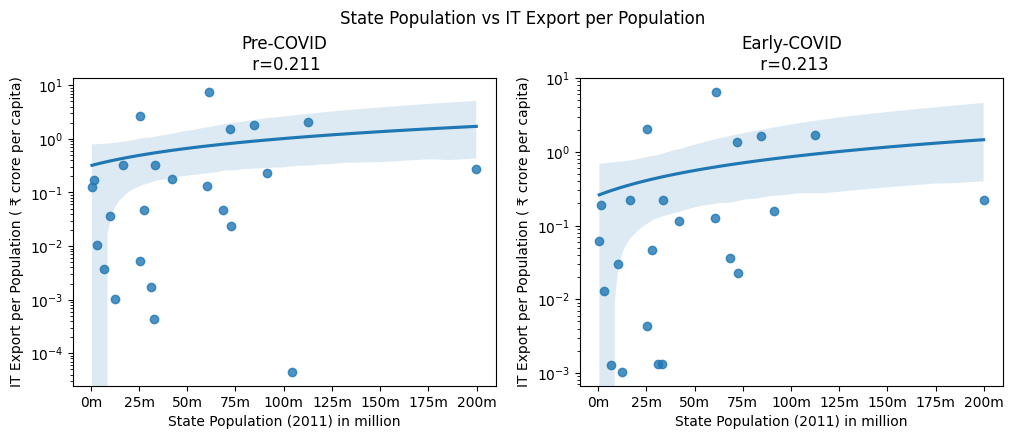

In [14]:
qplt2=""" select State,"Population 2011","Pre-COVID","Early-COVID" from dataset """
dfplt2=pd.read_sql(qplt2,conn)

import matplotlib.ticker as ticker

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}m")
)
dfplt2["Pre-COVID per capita"]=dfplt2["Pre-COVID"]/dfplt2["Population 2011"]
sns.regplot(
    x="Population 2011",y="Pre-COVID per capita",data=dfplt2)
corr3=dfplt2["Population 2011"].corr(dfplt2["Pre-COVID per capita"])
plt.title(f"Pre-COVID\n r={corr3:.3f}")
plt.xlabel("State Population (2011) in million")
plt.ylabel("IT Export per Population ( ₹ crore per capita)")
plt.yscale("log")

plt.subplot(1,2,2)
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}m")
)
dfplt2["Early-COVID per capita"]=dfplt2["Early-COVID"]/dfplt2["Population 2011"]
sns.regplot(
    x="Population 2011",y="Early-COVID per capita",data=dfplt2)
corr4=dfplt2["Population 2011"].corr(dfplt2["Early-COVID per capita"])
plt.title(f"Early-COVID\n r={corr4:.3f}")
plt.xlabel("State Population (2011) in million")
plt.ylabel("IT Export per Population ( ₹ crore per capita)")
plt.yscale("log")

plt.suptitle("State Population vs IT Export per Population",y="1.05")
plt.show()

Conclusion : The analysis of state population versus IT export per capita shows a weak positive correlation in both periods.

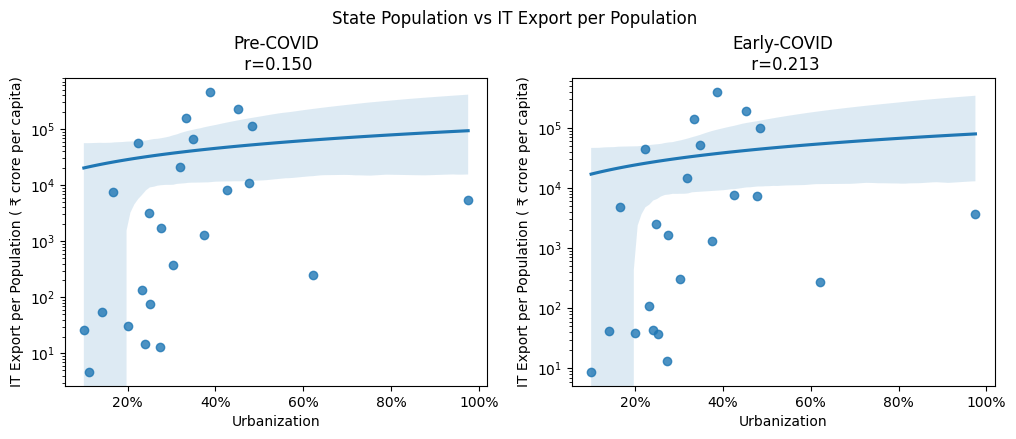

In [21]:
qplt3=""" select State,"Urban Population 2011","Population 2011","Pre-COVID","Early-COVID" from dataset """
dfplt3=pd.read_sql(qplt3,conn)

import matplotlib.ticker as ticker

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%")
)
dfplt3["Urbanization"]=(dfplt3["Urban Population 2011"]/dfplt3["Population 2011"])*100
sns.regplot(
    x="Urbanization",y="Pre-COVID",data=dfplt3)
corr5=dfplt3["Urbanization"].corr(dfplt3["Pre-COVID"])
plt.title(f"Pre-COVID\n r={corr5:.3f}")
plt.xlabel("Urbanization")
plt.ylabel("IT Export per Population ( ₹ crore per capita)")
plt.yscale("log")

plt.subplot(1,2,2)
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%")
)
dfplt3["Urbanization"]=(dfplt3["Urban Population 2011"]/dfplt3["Population 2011"])*100
sns.regplot(
    x="Urbanization",y="Early-COVID",data=dfplt3)
corr6=dfplt3["Urbanization"].corr(dfplt3["Early-COVID"])
plt.title(f"Early-COVID\n r={corr4:.3f}")
plt.xlabel("Urbanization")
plt.ylabel("IT Export per Population ( ₹ crore per capita)")
plt.yscale("log")

plt.suptitle("State Population vs IT Export per Population",y="1.05")
plt.show()

Conclusion : The analysis shows a weak positive relationship between urbanization and IT export per capita in both periods.
             Regression line indicates that states with higher urbanization levels tend to have slightly higher IT exports per capita, but the strength of the relationship remains weak.

OVERALL CONCLUSION :

Across all six visualizations, the relationship between demographic factors (Literacy Rate,Population Size and Urbanization Level) and IT Export Per Capita remains consistently weak in both the Pre-COVID and Early-COVID periods.

The correlation coefficients range approximately between -0.02 and 0.21, indicating only a marginal positive association. In practical terms, these variables explain less than 5% of the variation in IT export performance.

This suggests that:

Literally there is no roll for of a state's Literacy Rate in later IT Growth.

Larger population does not automatically translate into higher IT export intensity.

Higher urbanization is slightly more associated with IT exports than total population, but the effect remains weak.

The structural relationship between demographics and IT exports remained largely stable during the early COVID period.

IT export performance appears to depend more on ecosystem-level factors (technology clusters, skilled workforce concentration, policy environment, infrastructure) than on simple demographic scale.

LIMITATION :

1. The plots use logarithmic scaling for better visualization.
2. Even if urbanization shows a positive association, it does not prove that urbanization causes higher IT exports.
3. The analysis only compares Pre-COVID and Early-COVID periods.Long-term structural trends (10+ years) are not examined.

                                                            THANK YOU